# 3 · Boundary layer and profile drag

Thwaites (laminar) → Michel (transition) → Head (turbulent) → Squire–Young (drag), all driven
by the inviscid edge velocity from the panel method. See
[docs/boundary_layer.md](../docs/boundary_layer.md).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from aero import plotting as P

P.use_style()
DEG = np.pi / 180
from aero.panel_method_2d import solve_airfoil
from aero.boundary_layer import thwaites, viscous_drag

In [2]:
x = np.linspace(0, 0.2, 20001)
print("Howarth Ue = 1 - x: Thwaites separation at x =", round(thwaites(x, 1 - x, 1e5).s_sep, 4),
      "(exact 0.1199)")

Howarth Ue = 1 - x: Thwaites separation at x = 0.1232 (exact 0.1199)


In [3]:
for re in (1e6, 3e6, 6e6, 9e6):
    r = viscous_drag(solve_airfoil("0012", 0.0, 240), re)
    print(f"Re = {re:.0e}: cd = {r.cd:.5f} (friction {r.cd_friction:.5f}), "
          f"transition at x/c = {r.upper.x_transition:.2f} ({r.upper.transition_cause})")

Re = 1e+06: cd = 0.00823 (friction 0.00729), transition at x/c = 0.38 (michel)
Re = 3e+06: cd = 0.00733 (friction 0.00647), transition at x/c = 0.26 (michel)
Re = 6e+06: cd = 0.00679 (friction 0.00596), transition at x/c = 0.20 (michel)
Re = 9e+06: cd = 0.00643 (friction 0.00563), transition at x/c = 0.18 (michel)


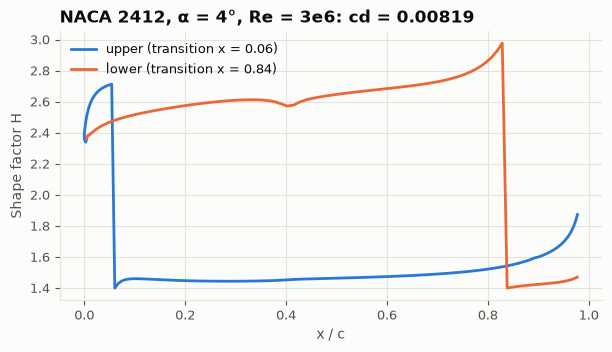

In [4]:
r = viscous_drag(solve_airfoil("2412", 4 * DEG, 240), 3e6)
fig, ax = plt.subplots(figsize=(7, 3.5))
for i, s in enumerate((r.upper, r.lower)):
    ax.plot(s.x, s.H, color=P.SERIES[i], label=f"{s.name} (transition x = {s.x_transition:.2f})")
ax.set_xlabel("x / c"); ax.set_ylabel("Shape factor H")
ax.set_title(f"NACA 2412, α = 4°, Re = 3e6: cd = {r.cd:.5f}"); ax.legend();